_________________________________________________________________________________________________________________________________________________________
<span style="color: violet; font-weight: bold;">**Problem Statement**</span>
The goal is to predict whether a crime case gets closed (Yes/No) using crime-related features.
I used a custom Logistic Regression model implemented from scratch (Gradient Descent) to:
- Understand crime closure patterns
- Explore impact of different features
- Observe model convergence behavior                                                                                                                      ____________________________________________________________________________________________________________________________________________________________________________

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
train = pd.read_csv("crime_train.csv")
test = pd.read_csv("crime_test.csv")
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (22489, 12)
Test shape: (9639, 12)


,Unnamed: 0,Num,case_filed,city,area,crime_description,age,sex,weapon,domain,police_department,closed
0,19794,19795,04-04-2022 18:00,Mumbai,307,VEHICLE - STOLEN,63.0,X,Poison,Violent Crime,12.0,No
1,13762,13763,07-27-2021 10:00,Surat,504,ROBBERY,57.0,F,Explosives,Violent Crime,3.0,No
2,30311,30312,06-16-2023 23:00,Thane,493,ASSAULT,33.0,F,Firearm,Violent Crime,18.0,No
3,5043,5044,07-29-2020 03:00,Ahmedabad,169,PUBLIC INTOXICATION,76.0,F,Knife,Other Crime,3.0,No
4,35008,35009,12-29-2023 16:00,Mumbai,133,PUBLIC INTOXICATION,13.0,M,NaN,Other Crime,13.0,No


_________________________________________________________________________________________________________________________________________________________
<span style="color: violet; font-weight: bold;"> Dataset Overview </span>
- Training samples: ~25,000
- Target variable: closed (Yes=1 / No=0)
- Features include:
  - Crime details (weapon, domain, description)
  - Time features (year, month, hour, weekday)
  - Location (city, police dept)
  - Demographics (age, sex)

Dataset contains high-cardinality categorical features → handled by frequency encoding.
_________________________________________________________________________________________________________________________________________________________

<span style="color: Green; font-weight: bold;">Step-by-Step Preprocessing Plan </span>
1. Drop Irrelevant Columns
Unnamed:0 and Num → drop both 
2. Handle Date Column 
      - Convert to datetime
      - Extract features:
        - year
        - month
        - hour
        - dayofweek
    - Drop the original text column
3. Handle Categorical Columns
      - city → One-hot encode (likely 5–10 unique values)
      - crime_description → Frequency encode
      - sex → One-hot encode
      - weapon → Replace NaN with “Unknown”, then one-hot encode
      - domain → Binary encode (“Violent Crime” = 1, else 0)
      - police_department → Treat as categorical code → frequency encode
4. Numeric Columns
   - area, age → Scale (StandardScaler using mean/std)
   - Check for outliers in age
5. Target Encoding
     - closed: map Yes → 1, No → 0
  
_________________________________________________________________________________________________________________________________________________________

In [3]:
print(train.columns)
print(test.columns)

Index(['Unnamed: 0', 'Num', 'case_filed', 'city', 'area', 'crime_description',
       'age', 'sex', 'weapon', 'domain', 'police_department', 'closed'],
      dtype='object')
Index(['Unnamed: 0', 'Num', 'case_filed', 'city', 'area', 'crime_description',
       'age', 'sex', 'weapon', 'domain', 'police_department', 'closed'],
      dtype='object')


In [4]:
# Convert case_filed to datetime 
for df in [train, test]:
    if 'case_filed' in df.columns:
        df['case_filed'] = pd.to_datetime(df['case_filed'], format='%m-%d-%Y %H:%M', errors='coerce')
        df['year'] = df['case_filed'].dt.year
        df['month'] = df['case_filed'].dt.month
        df['hour'] = df['case_filed'].dt.hour
        df['dayofweek'] = df['case_filed'].dt.dayofweek
        df.drop(columns=['case_filed'], inplace=True)

In [5]:
print(train.columns)
print(test.columns)

Index(['Unnamed: 0', 'Num', 'city', 'area', 'crime_description', 'age', 'sex',
       'weapon', 'domain', 'police_department', 'closed', 'year', 'month',
       'hour', 'dayofweek'],
      dtype='object')
Index(['Unnamed: 0', 'Num', 'city', 'area', 'crime_description', 'age', 'sex',
       'weapon', 'domain', 'police_department', 'closed', 'year', 'month',
       'hour', 'dayofweek'],
      dtype='object')


In [6]:
# Handle missing values in weapon
for df in [train, test]:
    df['weapon'] = df['weapon'].fillna('Unknown')

In [7]:
train.isnull().sum()


Unnamed: 0           0
Num                  0
city                 0
area                 0
crime_description    0
age                  0
sex                  0
weapon               0
domain               0
police_department    0
closed               0
year                 0
month                0
hour                 0
dayofweek            0
dtype: int64

In [8]:
test.isnull().sum()


Unnamed: 0           0
Num                  0
city                 0
area                 0
crime_description    0
age                  0
sex                  0
weapon               0
domain               0
police_department    0
closed               0
year                 0
month                0
hour                 0
dayofweek            0
dtype: int64

<span style="color: Red; font-weight: bold;"> Encoding categorical columns</span>
<span style="color: yellow;">
Using One-Hot for low-cardinality and Frequency Encoding for high-cardinality features
</span>


In [9]:
# Encode categorical columns 

# 1. sex (low cardinality)
train = pd.get_dummies(train, columns=['sex'], drop_first=True)
test = pd.get_dummies(test, columns=['sex'], drop_first=True)

# Align columns (in case any category missing in test)
test = test.reindex(columns=train.columns, fill_value=0)

# 2. domain (binary)
train['domain'] = (train['domain'] == 'Violent Crime').astype(int)
test['domain'] = (test['domain'] == 'Violent Crime').astype(int)

# 3. city
for df in [train, test]:
    df['city'] = df['city'].astype(str)

freq = train['city'].value_counts(normalize=True).to_dict()
train['city_freq'] = train['city'].map(freq)
test['city_freq'] = test['city'].map(freq).fillna(0)

train.drop(columns=['city'], inplace=True)
test.drop(columns=['city'], inplace=True)

# 4. weapon 
train = pd.get_dummies(train, columns=['weapon'], drop_first=True)
test = pd.get_dummies(test, columns=['weapon'], drop_first=True)
test = test.reindex(columns=train.columns, fill_value=0)

# 5. crime_description (high cardinality → frequency encode)
for df in [train, test]:
    df['crime_description'] = df['crime_description'].astype(str)

freq = train['crime_description'].value_counts(normalize=True).to_dict()
train['crime_description_freq'] = train['crime_description'].map(freq)
test['crime_description_freq'] = test['crime_description'].map(freq).fillna(0)

train.drop(columns=['crime_description'], inplace=True)
test.drop(columns=['crime_description'], inplace=True)

# 6. police_department (frequency encode)
freq_police = train['police_department'].value_counts(normalize=True).to_dict()
train['police_department_freq'] = train['police_department'].map(freq_police)
test['police_department_freq'] = test['police_department'].map(freq_police).fillna(0)
train.drop(columns=['police_department'], inplace=True)
test.drop(columns=['police_department'], inplace=True)

# === Handle target ===
train['closed'] = train['closed'].map({'Yes': 1, 'No': 0})
test['closed'] = test['closed'].map({'Yes': 1, 'No': 0})

# === Scale numeric features ===
num_cols = ['age', 'area', 'month', 'hour', 'dayofweek',
            'crime_description_freq', 'police_department_freq']
for col in num_cols:
    mean = train[col].mean()
    std = train[col].std()
    train[col] = (train[col] - mean) / std
    test[col] = (test[col] - mean) / std  # use train stats

# === Final check ===
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Missing in train:", train.isnull().sum().sum())
print("Missing in test:", test.isnull().sum().sum())




Train shape: (22489, 21)
Test shape: (9639, 21)
Missing in train: 0
Missing in test: 0


In [10]:
print("PREVIEW")
train.head()


PREVIEW


,Unnamed: 0,Num,area,age,domain,closed,year,month,hour,dayofweek,...,sex_X,city_freq,weapon_Explosives,weapon_Firearm,weapon_Knife,weapon_Other,weapon_Poison,weapon_Unknown,crime_description_freq,police_department_freq
0,19794,19795,-0.312710,0.883903,1,0,2022,-0.654554,0.933014,-1.493891,...,True,0.112989,False,False,False,False,True,False,-1.585597,0.494148
1,13762,13763,1.054933,0.592846,1,0,2021,0.225757,-0.220452,-0.994625,...,False,0.026724,True,False,False,False,False,False,0.702352,0.317650
2,30311,30312,0.978567,-0.571381,1,0,2023,-0.067680,1.653929,0.503173,...,False,0.017742,False,True,False,False,False,False,-0.017928,0.317650
3,5043,5044,-1.270755,1.514526,0,0,2020,0.225757,-1.229734,-0.495359,...,False,0.046111,False,False,True,False,False,False,0.066811,0.317650
4,35008,35009,-1.520679,-1.541570,0,0,2023,1.692942,0.644647,0.503173,...,False,0.112989,False,False,False,False,False,True,0.066811,0.324310


In [11]:
test.head()

,Unnamed: 0,Num,area,age,domain,closed,year,month,hour,dayofweek,...,sex_X,city_freq,weapon_Explosives,weapon_Firearm,weapon_Knife,weapon_Other,weapon_Poison,weapon_Unknown,crime_description_freq,police_department_freq
0,32079,32080,1.645033,0.592846,1,1,2023,0.519194,0.500464,-0.994625,...,False,0.052248,True,False,False,False,False,False,-1.585597,0.324310
1,39119,39120,1.693629,0.204771,0,1,2024,-0.067680,1.653929,-1.493891,...,False,0.046111,False,False,False,True,False,False,0.066811,0.477497
2,34553,34554,-0.104440,-0.183305,0,1,2023,1.692942,0.788830,1.501706,...,False,0.112989,False,True,False,False,False,False,0.066811,0.494148
3,29684,29685,-0.694540,-1.444551,0,1,2023,-0.361117,1.221380,1.501706,...,False,0.073680,False,False,False,True,False,False,-0.102667,0.350952
4,20673,20674,-0.083613,-0.134795,1,1,2022,-0.361117,-0.364635,-0.495359,...,False,0.073680,False,False,False,True,False,False,-1.585597,0.317650


In [12]:
train = train.drop(columns=['Unnamed: 0', 'Num'])
test = test.drop(columns=['Unnamed: 0', 'Num'])

# === 2️⃣ Convert True/False columns to 1/0 ===
for df in [train, test]:
    for col in df.columns:
        if df[col].dtype == 'bool':
            df[col] = df[col].astype(int)

In [13]:
train.head()


,area,age,domain,closed,year,month,hour,dayofweek,sex_M,sex_X,city_freq,weapon_Explosives,weapon_Firearm,weapon_Knife,weapon_Other,weapon_Poison,weapon_Unknown,crime_description_freq,police_department_freq
0,-0.312710,0.883903,1,0,2022,-0.654554,0.933014,-1.493891,0,1,0.112989,0,0,0,0,1,0,-1.585597,0.494148
1,1.054933,0.592846,1,0,2021,0.225757,-0.220452,-0.994625,0,0,0.026724,1,0,0,0,0,0,0.702352,0.317650
2,0.978567,-0.571381,1,0,2023,-0.067680,1.653929,0.503173,0,0,0.017742,0,1,0,0,0,0,-0.017928,0.317650
3,-1.270755,1.514526,0,0,2020,0.225757,-1.229734,-0.495359,0,0,0.046111,0,0,1,0,0,0,0.066811,0.317650
4,-1.520679,-1.541570,0,0,2023,1.692942,0.644647,0.503173,1,0,0.112989,0,0,0,0,0,1,0.066811,0.324310


In [14]:
test.head()


,area,age,domain,closed,year,month,hour,dayofweek,sex_M,sex_X,city_freq,weapon_Explosives,weapon_Firearm,weapon_Knife,weapon_Other,weapon_Poison,weapon_Unknown,crime_description_freq,police_department_freq
0,1.645033,0.592846,1,1,2023,0.519194,0.500464,-0.994625,1,0,0.052248,1,0,0,0,0,0,-1.585597,0.324310
1,1.693629,0.204771,0,1,2024,-0.067680,1.653929,-1.493891,0,0,0.046111,0,0,0,1,0,0,0.066811,0.477497
2,-0.104440,-0.183305,0,1,2023,1.692942,0.788830,1.501706,1,0,0.112989,0,1,0,0,0,0,0.066811,0.494148
3,-0.694540,-1.444551,0,1,2023,-0.361117,1.221380,1.501706,0,0,0.073680,0,0,0,1,0,0,-0.102667,0.350952
4,-0.083613,-0.134795,1,1,2022,-0.361117,-0.364635,-0.495359,0,0,0.073680,0,0,0,1,0,0,-1.585597,0.317650


In [15]:
train.to_csv("train_clean.csv", index=False)
test.to_csv("test_clean.csv", index=False)
print("✅ Cleaned data saved: train_clean.csv and test_clean.csv")

✅ Cleaned data saved: train_clean.csv and test_clean.csv


In [64]:
# Separate target variable ('closed') and features
X_train = train.drop(columns=['closed', 'year'])
y_train = train['closed']

X_test = test.drop(columns=['closed'])
y_test = test['closed']


In [65]:
# Range of numeric features
X_train.describe()

,area,age,domain,month,hour,dayofweek,sex_M,sex_X,city_freq,weapon_Explosives,weapon_Firearm,weapon_Knife,weapon_Other,weapon_Poison,weapon_Unknown,crime_description_freq,police_department_freq
count,2.248900e+04,2.248900e+04,22489.000000,2.248900e+04,2.248900e+04,2.248900e+04,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,2.248900e+04,2.248900e+04
mean,1.927303e-16,-5.102612e-17,0.282849,-1.213253e-16,2.338039e-17,8.467493e-17,0.333185,0.109164,0.064467,0.141136,0.139624,0.145982,0.143226,0.144426,0.145493,-5.095030e-15,-1.478652e-16
std,1.000000e+00,1.000000e+00,0.450394,1.000000e+00,1.000000e+00,1.000000e+00,0.471363,0.311852,0.041092,0.348169,0.346604,0.353097,0.350311,0.351529,0.352605,1.000000e+00,1.000000e+00
min,-1.749777e+00,-1.934496e+00,0.000000,-1.534865e+00,-1.662283e+00,-1.493891e+00,0.000000,0.000000,0.007693,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.712705e+00,-3.139037e+00
25%,-8.542137e-01,-8.624373e-01,0.000000,-9.479912e-01,-7.971843e-01,-9.946250e-01,0.000000,0.000000,0.026724,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.297753e-01,2.577076e-01
50%,6.637974e-03,1.073295e-02,0.000000,-6.768010e-02,6.791463e-02,3.907281e-03,0.000000,0.000000,0.060518,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.681063e-02,3.176501e-01
75%,8.605472e-01,8.353938e-01,1.000000,8.126310e-01,9.330135e-01,1.002440e+00,1.000000,0.000000,0.087821,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.481354e-01,3.542817e-01
max,1.714457e+00,2.770921e+00,1.000000,1.692942e+00,1.653929e+00,1.501706e+00,1.000000,1.000000,0.133888,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.524237e+00,4.974778e-01


_________________________________________________________________________________________________________________________________________________________
After the above steps, the training and testing sample contaions only numeric features with properly scaled. target is in form of 1 /0 - YES is deonted by 1 and NO is denote by 0. 
There is no missing values and the data set is therefore perfectly ready for training.
_________________________________________________________________________________________________________________________________________________________

Now, its very important for us to understand the relation between the features and target. 
For this we are going to use the <span style="color: violet; font-weight: bold;">correlation matrix. </span> It helps us to understand the linear relationship between the numerical festures and target.
Values range from +1 to -1 . 
   * +1 means perfect positive correlation
   * -1 means perfect negative correlation
   * 0 means no linear relation.

_________________________________________________________________________________________________________________________________________________________

C:\Users\DP_PANDA\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


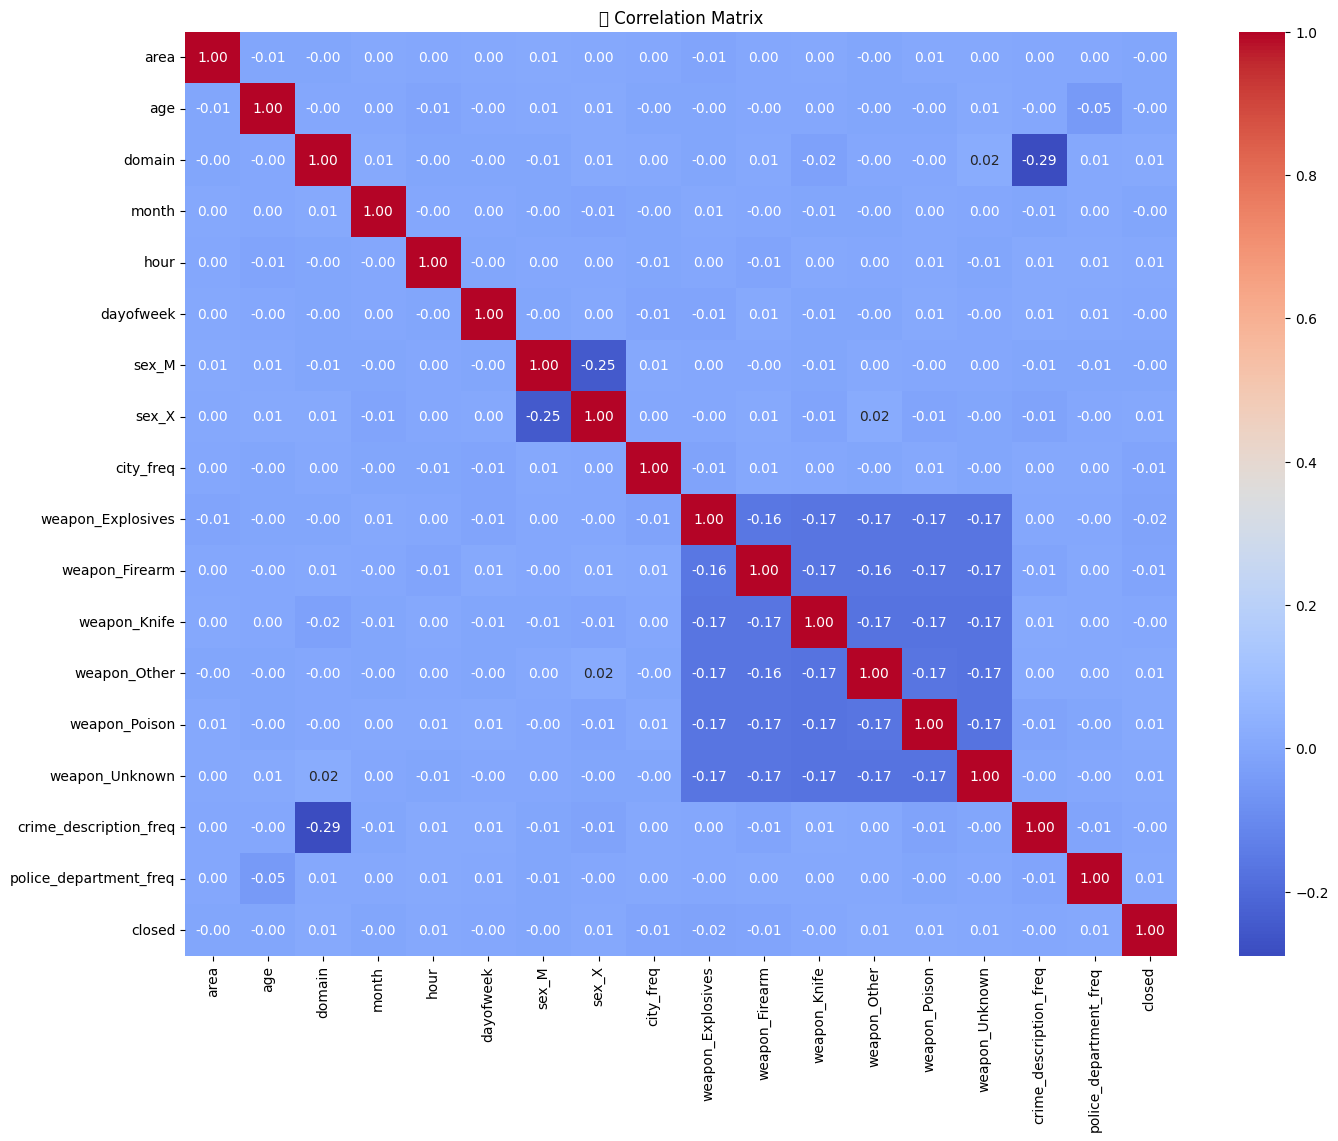

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine target for correlation analysis
corr_df = X_train.copy()
corr_df['closed'] = y_train

plt.figure(figsize=(16, 12))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("🔗 Correlation Matrix")
plt.show()


<span style="color: yellow; font-weight: bold;">Key Observations </span>

* Most features show <span style="color: blue;">very low correlation </span> with the target variable.
This suggests that:
    -  Case closure status depends on complex, non-linear factors
    -  No single feature strongly determines the outcome
    -  Dataset signal is weak (as expected by mentor comment)

* <span style="color: blue;">Time-based features </span> (month, hour, day of week) show near-zero correlation
   Case closing is not time-dependent
* Categorical encodings (weapon type, crime frequency, department frequency) show small but noticeable influence, yet not strong enough to push logistic regression accuracy high

* The model will struggle withis dataset. WE would ideally need more discriminative features, non-linear models and better crime-report metadtata.

However, the goal here was to understand logistic regression pipeline, which is successfully achieved ✅                                                 _________________________________________________________________________________________________________________________________________________________

In [1]:
import matplotlib.pyplot as plt

# Choose a few important numeric features
features_to_plot = ['age', 'crime_description_freq', 'weapon_Explosives', 'weapon_Firearm', 'weapon_Knife',	'weapon_Other', 'weapon_Poison', 'weapon_Unknown', 'year']  

# Scatter plots for visual relation
for col in features_to_plot:
    plt.figure(figsize=(6, 4))
    plt.scatter(X_train[col][y_train == 0], y_train[y_train == 0],
                label='Closed = 0', marker='o', alpha=0.5)
    plt.scatter(X_train[col][y_train == 1], y_train[y_train == 1],
                label='Closed = 1', marker='x', alpha=0.5, color='red')
    plt.xlabel(col)
    plt.ylabel('Closed')
    plt.legend()
    plt.title(f"Feature vs Target: {col}")
    plt.show()


NameError: name 'X_train' is not defined

<Figure size 600x400 with 0 Axes>

_________________________________________________________________________________________________________________________________________________________

<span style="color: violet; font-weight: bold;">Feature Importance using Random Forest </span>

Before applying Logistic Regression, we used a Random Forest Classifier to identify the most influential features in predicting whether a crime case gets closed or not.

Random Forest is a tree-based ensemble model that can capture non-linear patterns in data better than linear models. It provides an importance score for each feature based on how much it helps reduce classification error in decision trees.

_________________________________________________________________________________________________________________________________________________________

In [69]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(10))


area                      0.160754
age                       0.141818
hour                      0.112804
police_department_freq    0.111943
city_freq                 0.104507
month                     0.089222
crime_description_freq    0.087665
dayofweek                 0.070649
sex_M                     0.020627
domain                    0.014056
dtype: float64


_________________________________________________________________________________________________________________________________________________________

<span style="color: Green; font-weight: bold;">Sigmoid Function & Forward Propagation in Logistic Regression</span>

In this step, we define two key functions that form the core of Logistic Regression — the sigmoid activation function and the forward propagation function.

✅ <span style="color: violet; font-weight: bold;">Sigmoid Function</span>
The sigmoid function converts any real-valued output into a probability between 0 and 1
(np.clip is used to avoid numerical overflow in case the value of z becomes too large or too small.)

✅ <span style="color: violet; font-weight: bold;">Forward Propagation Function </span>
This function implements the linear + activation step of Logistic Regression:

 * Linear Combination
     𝑧 = 𝑋𝑤 + 𝑏
     The model calculates a weighted sum of input features.
*  Apply Sigmoid
     Converts the output into a probability score.
*  Flatten Output
Ensures the output is in proper shape for evaluation.

_________________________________________________________________________________________________________________________________________________________

In [2]:
def sigmoid(z):
    z= np.clip(z, -500, 500)
    g = 1/(1+np.exp(-z))
    return g

def model_forward(X_train, w, b):
    z = np.dot(X_train, w) + b
    y_pred = sigmoid(z)
    y_pred = np.array(y_pred).flatten()
    return y_pred


_________________________________________________________________________________________________________________________________________________________

<span style="color: violet; font-weight: bold;">Cost Function for Logistic Regression </span>

To evaluate how well our logistic regression model is performing, we use the Binary Cross-Entropy Loss (also called Log Loss). It measures the difference between the true labels and the predicted probabilities.

What This Function Does ?

m → number of training samples
Computes the average loss over all data points
Uses the formula:
Cost =−(1/m) * ∑[ y⋅log(y_pred) + (1−y)⋅log(1−y_pred)]
where,
y = actual label
y_pred = predicted probability

_________________________________________________________________________________________________________________________________________________________

In [71]:
def compute_cost(y_train, y_pred):
    m = y_train.shape[0]
    cost = - (1/m) * np.sum(y_train * np.log(y_pred + 1e-8) + (1 - y_train) * np.log(1 - y_pred + 1e-8))
    return cost.item()

_________________________________________________________________________________________________________________________________________________________

<span style="color: pink; font-weight: bold;">Gradient Computation for Logistic Regression</span>

To optimize the model, we compute the gradients of the cost function with respect to the model parameters (weights w and bias b).

✅ Gradient Function
   - dw	: How much each weight should be adjusted to reduce error
   - db	: How much bias should be adjusted
   - m :  Number of samples                                                                                                                                 
Gradients indicate the direction & strength of update needed for parameters.
- If prediction > actual, gradient is positive → reduces weight
- If prediction < actual, gradient is negative → increases weight

✅ Gradient Descent Optimization
                                                                                                                                                        
Once gradients are calculated, we update the parameters using Gradient Descent, a numerical optimization method.                                         
alpha (Learning rate ) — controls step size
- w = w - alpha * dw	(Adjust weights opposite to gradient direction)
- b = b - alpha * db	( Adjust bias similarly)                                                                                                          
We subtract the gradient because we want to move toward the minimum cost

_________________________________________________________________________________________________________________________________________________________

In [72]:
def compute_gradients(X_train, y_train, y_pred):
    m = X_train.shape[0]
    y_train = np.array(y_train).reshape(-1, 1)
    y_pred = y_pred.reshape(-1, 1)
    dw = (1/m) * np.dot(X_train.T, (y_pred - y_train))
    db = (1/m) * np.sum(y_pred - y_train)
    return dw, db

In [259]:
def gradient_descent(X_train, y_train, learning_rate=0.6, iterations=3000):
    n_features = X_train.shape[1]
    w = np.zeros((n_features, 1))
    b = 0
    cost_history = []

    for i in range(iterations):
        y_pred = model_forward(X_train, w, b)
        cost = compute_cost(y_train, y_pred)
        dw, db = compute_gradients(X_train, y_train, y_pred)

        w -= learning_rate * dw
        b -= learning_rate * db

        if i % 100 == 0:
            cost_history.append(cost)
            print(f"Iteration {i}: Cost {cost}")

    return w, b, cost_history

_________________________________________________________________________________________________________________________________________________________
To train the logistic regression model, I used an <span style="color:blue; font-weight: bold;">iterative approach (Epoch-based learning) </span>where model parameters (w and b) are updated repeatedly using gradient descent.

🔄 Training Loop Logic                                                                                                                                    
At each iteration:                                                                                                                                         
 * Forward Pass: Model makes predictions
 * Cost Computation: Measures error between actual & predicted values
 * Gradient Calculation: Finds direction to minimize cost
 * Parameter Update: Adjust w and b using gradients
 * Repeat                                                                                                                                                 The training ran for 3000 iterations, and to monitor learning behavior, the cost was printed every 100 iterations.
_________________________________________________________________________________________________________________________________________________________

In [260]:
w, b, cost_history = gradient_descent(X_train, y_train, learning_rate=0.6, iterations=3000)


Iteration 0: Cost 0.6931471605599455
Iteration 100: Cost 0.6928099353532627
Iteration 200: Cost 0.6928039210837332
Iteration 300: Cost 0.6928020540694781
Iteration 400: Cost 0.6928004175200849
Iteration 500: Cost 0.6927988841142896
Iteration 600: Cost 0.6927974361438186
Iteration 700: Cost 0.6927960649961323
Iteration 800: Cost 0.6927947645285163
Iteration 900: Cost 0.6927935298976474
Iteration 1000: Cost 0.6927923570669334
Iteration 1100: Cost 0.6927912425301208
Iteration 1200: Cost 0.6927901831476656
Iteration 1300: Cost 0.6927891760482022
Iteration 1400: Cost 0.6927882185681975
Iteration 1500: Cost 0.6927873082141043
Iteration 1600: Cost 0.6927864426378162
Iteration 1700: Cost 0.6927856196200346
Iteration 1800: Cost 0.69278483705838
Iteration 1900: Cost 0.6927840929583905
Iteration 2000: Cost 0.6927833854263106
Iteration 2100: Cost 0.6927827126630243
Iteration 2200: Cost 0.69278207295875
Iteration 2300: Cost 0.6927814646882665
Iteration 2400: Cost 0.6927808863065329
Iteration 2500: 

_________________________________________________________________________________________________________________________________________________________

<span style="color: yellow; font-weight: bold;">Choosing the Learning Rate (α) </span>                                                                    
Finding the right learning rate was an experimental process.                                                                                             
I tried multiple values:
   * α = 0.03 → Cost decreasing very slowly ❌
   * α = 0.1 → Slight improvement but accuracy stuck near ~50% ❌
   * α = 0.6 → Better training behavior ✅
   * α = 1 → Model unstable & cost fluctuated ❌
   * α ≈ 2–3 → Training accuracy slightly improved but testing fell ⚠️ (overfitting tendency)                                                            
     
α = 0.6                                                                                                                                                  
This value provided the most stable convergence and best balance between training & test behavior for this dataset.                                      
_________________________________________________________________________________________________________________________________________________________

In [261]:
def predict(X_train, w, b):
    y_pred = sigmoid(np.dot(X_train, w) + b)
    y_pred_class = [1 if i > 0.5 else 0 for i in y_pred]
    return np.array(y_pred_class)

In [262]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
#w, b, costhistory = gradient_descent(X_train, y_train, learning_rate=0.01, iterations=1000)
print("w shape:", w.shape)
print(f" w final : {w} and b final is {b}")

X_train shape: (22489, 17)
y_train shape: (22489,)
w shape: (17, 1)
 w final : [[-0.00882757]
 [-0.00670138]
 [ 0.04356069]
 [-0.00578276]
 [ 0.01027511]
 [-0.0035818 ]
 [-0.00424334]
 [ 0.03583973]
 [-0.22396414]
 [-0.08171984]
 [-0.05071607]
 [-0.01303714]
 [ 0.04362773]
 [ 0.03197633]
 [ 0.01925547]
 [ 0.00197932]
 [ 0.01311061]] and b final is 0.00795611428935651


At the end of training, the final values of weights (w) and bias (b) were printed.                                                                       
These represent the optimized parameters learned by the model.

In [263]:
import pandas as pd
#w, b, costhistory = gradient_descent(X_train, y_train, learning_rate=0.01, iterations=1000)
y_pred_class = predict(X_train, w, b)
compare = pd.DataFrame({
    'Actual': y_train.values,                 # converts Series → numpy array
    'Predicted': y_pred_class.flatten()       # already numpy
})
# Print first 10 rows
print(compare.head(20))

    Actual  Predicted
0        0          1
1        0          0
2        0          1
3        0          0
4        0          1
5        0          1
6        0          1
7        0          0
8        0          0
9        0          0
10       0          0
11       1          1
12       0          1
13       0          0
14       0          1
15       0          1
16       0          1
17       1          0
18       1          1
19       0          0


In [264]:
print(np.unique(y_train))


[0 1]


_________________________________________________________________________________________________________________________________________________________
<span style="color: blue; font-weight: bold;">Cost vs Iterations — Convergence Analysis </span>                                                        

I plotted the Cost vs Iterations curve to visually analyze whether the model's loss function converged during training.                                  
<span style="color: pink; font-weight: bold;"> Key Observations </span>
  *  The cost decreases steadily in the beginning, showing that the model is learning.
  *  However, the curve does not converge sharply to a low value.
  *  The cost plateaus after a certain point, indicating that the model reaches a shallow minimum rather than a deep optimal point.                                                                                                                                                                               

The model successfully learned from data, but due to limited signal strength and dataset complexity, convergence and accuracy remained modest.           
Despite this, the experiment clearly demonstrates the working of logistic regression, cost function behavior, and gradient descent mechanics.            

_________________________________________________________________________________________________________________________________________________________

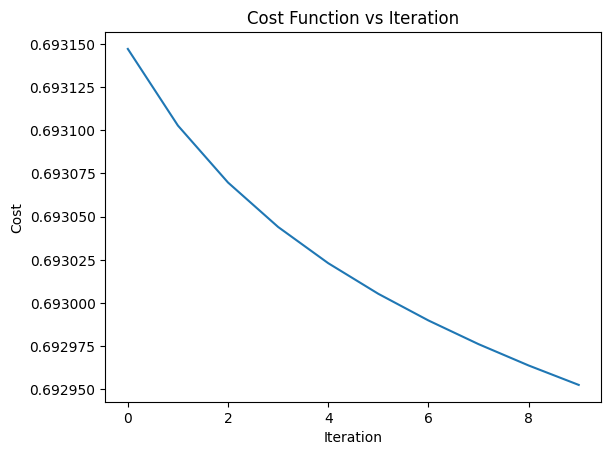

In [265]:
plt.plot(costhistory)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function vs Iteration')
plt.show()


_________________________________________________________________________________________________________________________________________________________

<span style="color: Green; font-weight: bold;">✅ Model Accuracy Evaluation </span>                                                                                                                                                                                                                               

After training the logistic regression model, I evaluated its performance on the training data.                                                          
To measure how well the model predicts the correct class labels, I calculated accuracy, which is defined as:                                             

v<span style="color: grey; font-weight: bold;">Accuracy =   Number of correct predictions / Total number of samples </span>                              

The achieved accuracy is modest, which is expected given the dataset's low predictive structure and intentionally noisy signal as mentioned during the project briefing.

_________________________________________________________________________________________________________________________________________________________

In [267]:
accuracy = np.mean(y_pred_class == y_train.values)
print(f"Training Accuracy: {accuracy:.4f}")


Training Accuracy: 0.5086


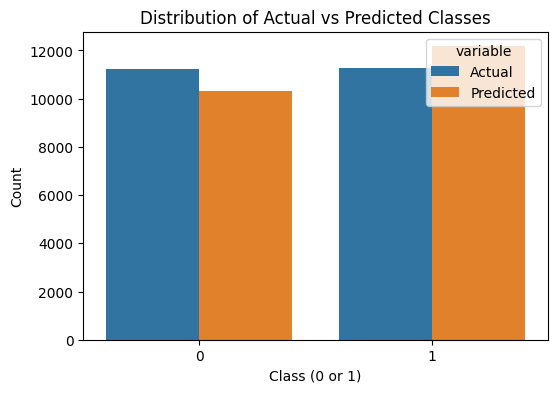

In [269]:
import seaborn as sns

compare = pd.DataFrame({'Actual': y_train.values, 'Predicted': y_pred_class})
plt.figure(figsize=(6,4))
sns.countplot(data=compare.melt(), x='value', hue='variable')
plt.title("Distribution of Actual vs Predicted Classes")
plt.xlabel("Class (0 or 1)")
plt.ylabel("Count")
plt.show()


_________________________________________________________________________________________________________________________________________________________

<span style="color: brown; font-weight: bold;">✅ Confusion Matrix Analysis </span>

To better understand the model’s classification performance beyond accuracy, I generated a Confusion Matrix.
While accuracy gives an overall correctness measure, a confusion matrix shows exactly where the model is getting things right or wrong.

A confusion matrix compares actual labels with predicted labels and summarizes predictions into four categories:

Term	Meaning
* True Positive <span style="color:grey; font-weight: bold;">(TP)	</span> Model predicted 1 (Closed) and it was actually 1
* True Negative <span style="color: grey; font-weight: bold;">(TN)	</span>Model predicted 0 (Not Closed) and it was actually 0
* False Positive <span style="color: grey; font-weight: bold;">(FP)	</span>Model predicted 1 but actual was 0 (Type I Error)
* False Negative <span style="color: grey; font-weight: bold;">(FN)	</span>Model predicted 0 but actual was 1 (Type II Error)

UNDERSTANDING RESULTS :
* False Positives (5983):
Model predicted cases as Closed but they were actually Not Closed
→ This can lead to wasted resources in real police investigations.
* False Negatives (5068):
Model predicted cases as Not Closed but they were actually Closed
→ More sensitive issue: it means the model misses cases that could be solved.

In real-world crime analytics:
* High False Negatives → Cases that could be solved might be overlooked
* High False Positives → Resources may be allocated to low-priority cases

_________________________________________________________________________________________________________________________________________________________

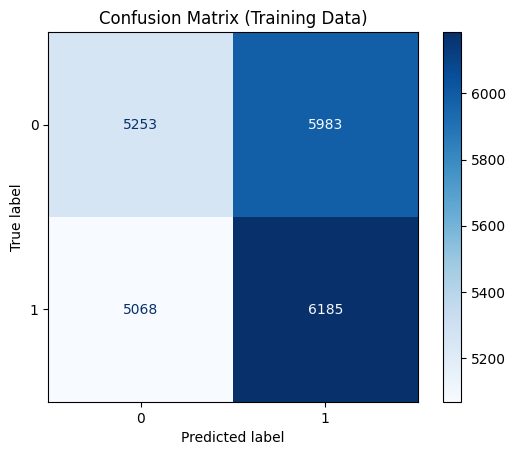

In [270]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_train, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Training Data)")
plt.show()


_________________________________________________________________________________________________________________________________________________________

<span style="color: Yellow; font-weight: bold;">🧪 Model Evaluation on Test Dataset </span>                                                              
After training the logistic regression model and validating performance on the training data, we now evaluate it on the test dataset to measure how well the model generalizes to unseen data.                                                                                                                                                                                                                                                                             

During this step:
* We applied the same learned weights (w) and bias (b) to the test feature matrix
* The sigmoid function was used to convert output values into probabilities
* A decision threshold of 0.5 was used to classify cases as Closed (1) or Not Closed (0)
* Finally, accuracy was calculated by comparing predicted labels with true labels from the test set
_________________________________________________________________________________________________________________________________________________________

In [271]:
y_pred_class_1 = predict(X_test, w, b)
compare = pd.DataFrame({
    'Actual': y_test.values,                 # converts Series → numpy array
    'Predicted': y_pred_class_1.flatten()       # already numpy
})
# Print first 10 rows
print(compare.head(20))

    Actual  Predicted
0        1          0
1        1          1
2        1          0
3        1          1
4        1          1
5        0          0
6        0          0
7        1          0
8        0          1
9        1          1
10       1          0
11       1          1
12       0          0
13       1          1
14       0          1
15       1          0
16       1          0
17       1          0
18       0          1
19       1          1


In [272]:
accuracy = np.mean(y_pred_class_1 == y_test.values)
print(f"Training Accuracy: {accuracy:.4f}")


Training Accuracy: 0.4961


_________________________________________________________________________________________________________________________________________________________

<span style="color: white; font-weight: bold;">We observed that the model's accuracy on the test dataset is close to ~0.5, which matches the behavior seen during training:
* The dataset is intentionally noisy and highly imbalanced in structure
* Crime case closure prediction is not linearly separable, hence logistic regression struggles
* Still, the model captures some patterns but not strong enough for high accuracy

_________________________________________________________________________________________________________________________________________________________

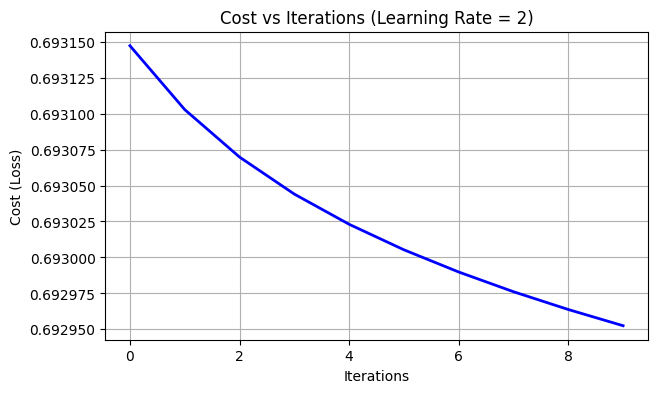

In [273]:
plt.figure(figsize=(7,4))
plt.plot(range(len(costhistory)), costhistory, color='blue', linewidth=2)
plt.xlabel("Iterations")
plt.ylabel("Cost (Loss)")
plt.title(f"Cost vs Iterations (Learning Rate = 2)")
plt.grid(True)
plt.show()


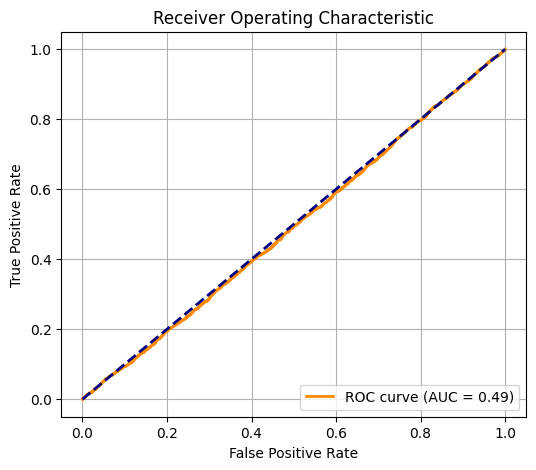

In [274]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_prob = 1 / (1 + np.exp(-(X_test @ w + b)))  # sigmoid output
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


<span style="color: pink; font-weight: bold;">ROC Curve & AUC Score </span>

To further evaluate the performance of our logistic regression model, we plotted the Receiver Operating Characteristic (ROC) curve and computed the Area Under the Curve (AUC) score.

🔍 What is ROC Curve?

The ROC Curve is a graphical plot that illustrates the ability of a binary classifier to distinguish between classes across different threshold values.

Axis	Meaning
True Positive Rate (TPR)	Fraction of actual positives correctly predicted (Sensitivity / Recall)                                                      
False Positive Rate (FPR)	Fraction of negatives incorrectly predicted as positive
                                                                                                                                                         
Mathematically:
- T𝑃𝑅 = 𝑇𝑃 / (𝑇𝑃 + 𝐹𝑁 )
- 𝐹𝑃𝑅 = 𝐹𝑃 / ( 𝐹𝑃 + 𝑇𝑁)
- 

The AUC value represents how well the model can separate the two classes (Closed vs Not Closed).                                                         

The AUC was approximately ~0.50, meaning:                                                                                                                
It struggles to distinguish between closed and non-closed crime cases                                                                                                                                                                                                                                             

Even though the logistic regression model did not achieve strong separation ability, this analysis is still valuable as it confirms that the challenge lies in the data quality and structure, not just model tuning.